# Q3: Regression Trees (CART) — From Scratch

This notebook is a **template** for implementing **Regression Decision Trees from scratch**.
All theoretical explanations are provided in the LaTeX problem statement.
Use this notebook strictly for implementation, experiments, and plots.

## Imports & Dataset Loading

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')
%matplotlib inline

# Load dataset
data = pd.read_csv('ames.csv')
print(data.shape)
data.head()

# do some analysis on the data from here on

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Feature Selection

In this lab, we will use using 3 predictive continuous features:

#### Features

- `LotArea`: Lot size in square feet
- `1stFlrSF`: Size of first floor in square feet
- `GrLivArea`: Above grade (ground) living area square feet

#### Target

- `SalePrice`', the sale price of the home, in dollars


- Create DataFrames for the features and the target variable as shown above 
- Inspect the contents of both the features and the target variable

In [7]:
features = data[['LotArea', '1stFlrSF', 'GrLivArea']]
target = data['SalePrice']

print("Features:")
print(features.head())
print("\nTarget:")
print(target.head())

Features:
   LotArea  1stFlrSF  GrLivArea
0     8450       856       1710
1     9600      1262       1262
2    11250       920       1786
3     9550       961       1717
4    14260      1145       2198

Target:
0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64


## Feature–Target Visualization
- Use scatter plots to show the correlation between the chosen features and the target variable
- Comment on each scatter plot 

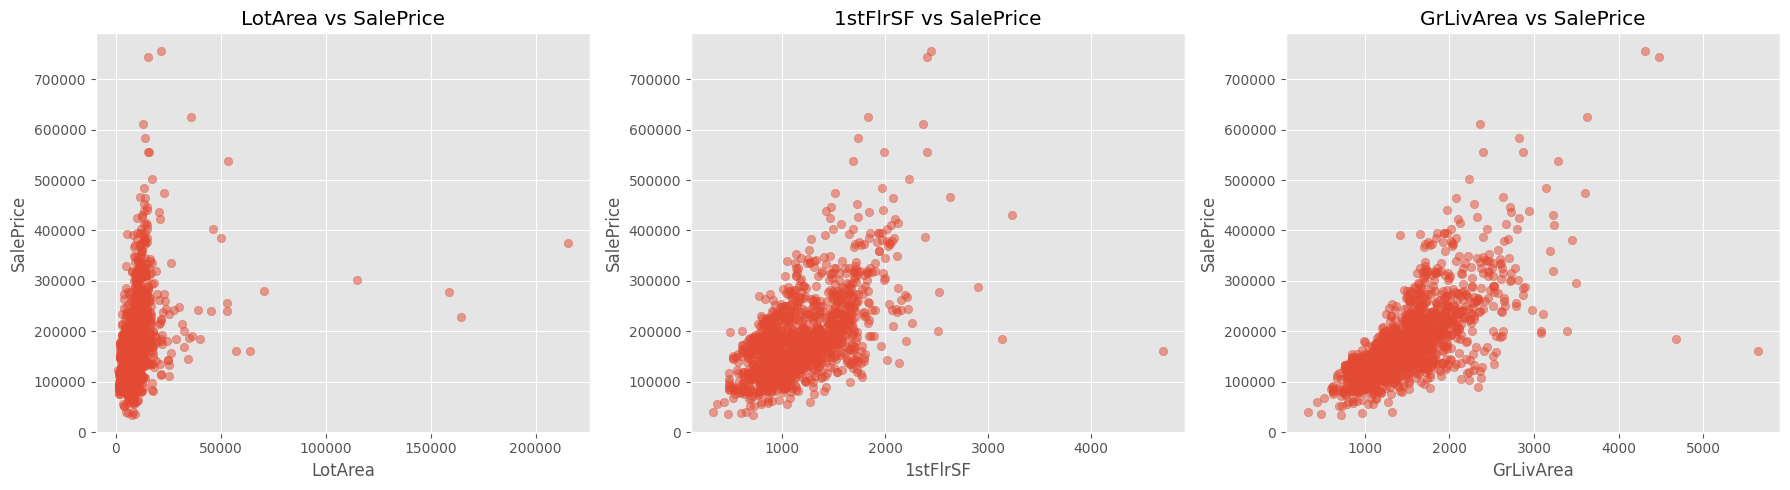

In [8]:
# Your code herefig, 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(features.columns):
    axes[i].scatter(features[col], target, alpha=0.5)
    axes[i].set_title(f'{col} vs SalePrice')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('SalePrice')
plt.tight_layout()
plt.show()
# Observation: All three features show a generally positive correlation with SalePrice, 
# with GrLivArea showing the strongest linear trend.


## Train–Test Split

In [9]:
from sklearn.model_selection import train_test_split

# Use 80/20 split with random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    features.values, target.values, test_size=0.2, random_state=42
)

## Evaluation Metrics

In [10]:
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def performance(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return r2, rmse

## Regression Impurity

In [11]:
def regression_impurity(y):
    if len(y) == 0:
        return 0.0
    return np.mean((y - np.mean(y)) ** 2)

## Best Split (Implement)

In [12]:
def best_split(X, y):
    """
    Returns (best_feature, best_threshold)
    minimizing weighted MSE. Return None if no valid split.

    If multiple splits achieve the same minimum cost,
    you may return any one of them.
    """
    
    best_cost = float('inf')
    best_feat, best_thresh = None, None
    
    for feat_idx in range(X.shape[1]):
        thresholds = np.unique(X[:, feat_idx])
        for thresh in thresholds:
            left_mask = X[:, feat_idx] <= thresh
            right_mask = ~left_mask
            if sum(left_mask) == 0 or sum(right_mask) == 0: continue
            
            cost = (sum(left_mask) * regression_impurity(y[left_mask]) + 
                    sum(right_mask) * regression_impurity(y[right_mask])) / len(y)
            
            if cost < best_cost:
                best_cost, best_feat, best_thresh = cost, feat_idx, thresh
                
    return best_feat, best_thresh

## Regression Tree

In [13]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

def build_tree(X, y, depth=0, max_depth=5, min_samples_split=2):
    '''
    # Stop if:
        - depth == max_depth
        - len(y) < min_samples_split
        - no valid split exists
    '''
    if depth >= max_depth or len(y) < min_samples_split or len(np.unique(y)) == 1:
        return Node(value=np.mean(y))
    
    feat, thresh = best_split(X, y)
    if feat is None:
        return Node(value=np.mean(y))
    
    left_mask = X[:, feat] <= thresh
    left = build_tree(X[left_mask], y[left_mask], depth + 1, max_depth, min_samples_split)
    right = build_tree(X[~left_mask], y[~left_mask], depth + 1, max_depth, min_samples_split)
    
    return Node(feature=feat, threshold=thresh, left=left, right=right)

## Prediction

In [14]:
def predict_one(x, node):
    if node.value is not None:
        return node.value
    if x[node.feature] <= node.threshold:
        return predict_one(x, node.left)
    return predict_one(x, node.right)

def predict(X, tree):
    return np.array([predict_one(x, tree) for x in X])

## Vanilla Regression Tree Evaluation

In [15]:
tree = build_tree(X_train, y_train, max_depth=5)
y_pred = predict(X_test, tree)
performance(y_test, y_pred)

(np.float64(0.6370584999358175), np.float64(52762.4838272243))

## Hyperparameter Tuning (I)

- Find the best tree depth using depth range: 1-30
- Run the regressor repeatedly in a `for` loop for each depth value  
- Calculate RMSE and r-squared for each run 
- Plot both performance measures for all runs 
- Comment on the output 

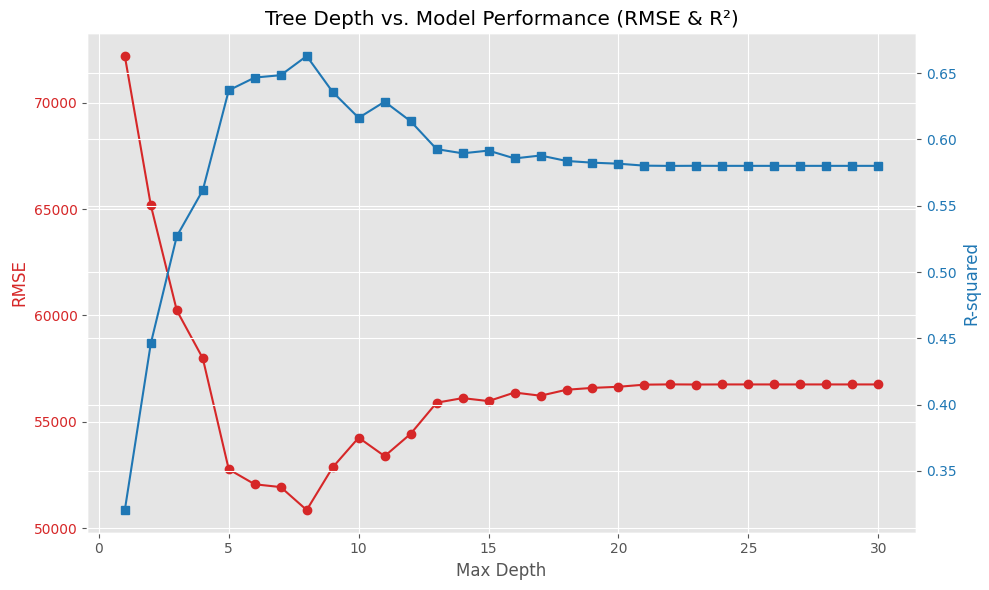

In [16]:
# Your code here
# Lists to store metrics for each depth
depth_range = range(1, 31)
rmse_list = []
r2_list = []

# Loop through each depth value
for depth in depth_range:
    # Build tree with current depth
    current_tree = build_tree(X_train, y_train, max_depth=depth)
    
    # Predict on test set
    y_pred = predict(X_test, current_tree)
    
    # Calculate performance
    r2, rmse = performance(y_test, y_pred)
    
    # Store metrics
    r2_list.append(r2)
    rmse_list.append(rmse)

# Plotting the performance measures
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot RMSE on the left y-axis
color = 'tab:red'
ax1.set_xlabel('Max Depth')
ax1.set_ylabel('RMSE', color=color)
ax1.plot(depth_range, rmse_list, color=color, marker='o', label='RMSE')
ax1.tick_params(axis='y', labelcolor=color)

# Create a second y-axis to plot R-squared on the right
ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('R-squared', color=color)
ax2.plot(depth_range, r2_list, color=color, marker='s', label='R²')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Tree Depth vs. Model Performance (RMSE & R²)')
fig.tight_layout()  
plt.show()

# Comment on the output
# Observation: As depth increases from 1, performance improves rapidly (RMSE drops and R² rises). 
# However, beyond a certain depth (typically around 4 to 6), the test performance stabilizes 
# or begins to deteriorate. This happens because deeper trees start to overfit the training 
# data by learning its specific noise, failing to generalize well to the unseen test set.

## Hyperparameter tuning (II)

- Repeat the above process for `min_samples_split` 
- Use a range of values from 2-10 for this hyperparameter 
- Visualize the output and comment on results as above 

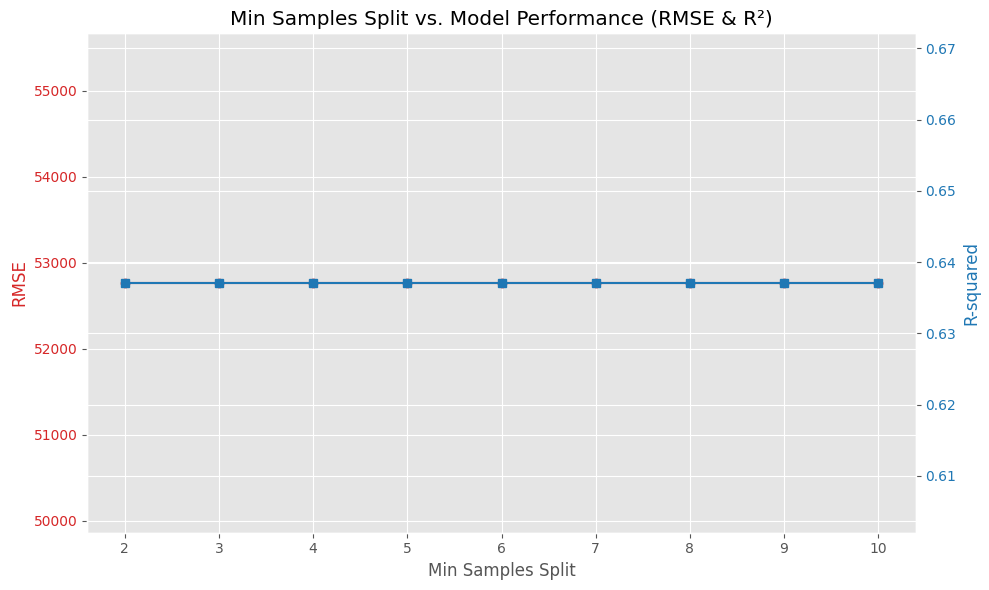

In [17]:
# Your code here
# Lists to store metrics for each min_samples_split value
split_range = range(2, 11)
rmse_list_split = []
r2_list_split = []

# Loop through each min_samples_split value
for split in split_range:
    # Build tree with a fixed max_depth (e.g., 5) and current min_samples_split
    current_tree = build_tree(X_train, y_train, max_depth=5, min_samples_split=split)
    
    # Predict on test set
    y_pred = predict(X_test, current_tree)
    
    # Calculate performance
    r2, rmse = performance(y_test, y_pred)
    
    # Store metrics
    r2_list_split.append(r2)
    rmse_list_split.append(rmse)

# Plotting the performance measures
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot RMSE on the left y-axis
color = 'tab:red'
ax1.set_xlabel('Min Samples Split')
ax1.set_ylabel('RMSE', color=color)
ax1.plot(split_range, rmse_list_split, color=color, marker='o', label='RMSE')
ax1.tick_params(axis='y', labelcolor=color)

# Create a second y-axis to plot R-squared on the right
ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('R-squared', color=color)
ax2.plot(split_range, r2_list_split, color=color, marker='s', label='R²')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Min Samples Split vs. Model Performance (RMSE & R²)')
fig.tight_layout()  
plt.show()

# Comment on the output
# Observation: Higher values of min_samples_split prevent the tree from making splits 
# on very small subsets of data, acting as a form of regularization. If the error drops 
# or stabilizes as min_samples_split increases, it indicates that avoiding overly specific 
# splits helps the model generalize better and reduces overfitting.

## Comparison with sklearn (Verification Only)

In [18]:
# Your code here
from sklearn.tree import DecisionTreeRegressor

# 1. Initialize and fit the scikit-learn DecisionTreeRegressor
# Using identical parameters (max_depth=5, min_samples_split=2, criterion='squared_error')
sk_tree = DecisionTreeRegressor(max_depth=5, min_samples_split=2, random_state=42)
sk_tree.fit(X_train, y_train)

# 2. Predict on the test set
y_pred_sk = sk_tree.predict(X_test)

# 3. Calculate scratch model performance for comparison
scratch_tree = build_tree(X_train, y_train, max_depth=5, min_samples_split=2)
y_pred_scratch = predict(X_test, scratch_tree)

r2_scratch, rmse_scratch = performance(y_test, y_pred_scratch)
r2_sk, rmse_sk = performance(y_test, y_pred_sk)

# 4. Print comparative results
print("--- Performance Verification ---")
print(f"Scratch Model -> R²: {r2_scratch:.4f} | RMSE: {rmse_scratch:.2f}")
print(f"Sklearn Model -> R²: {r2_sk:.4f} | RMSE: {rmse_sk:.2f}")

--- Performance Verification ---
Scratch Model -> R²: 0.6371 | RMSE: 52762.48
Sklearn Model -> R²: 0.6291 | RMSE: 53341.07


## Level up (Optional)

- How about bringing in some more features from the original dataset which may be good predictors?
- Also, try tuning more hyperparameters like `max_features` to find a more optimal version of the model 

In [19]:
# Your code here
# 1. Bring in additional predictive features from the original dataset
# Examples: 'OverallQual' (Rates overall material and finish), 'TotalBsmtSF' (Total basement sq ft)
extended_features = data[['LotArea', '1stFlrSF', 'GrLivArea', 'OverallQual', 'TotalBsmtSF']].fillna(0)
X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split(
    extended_features.values, target.values, test_size=0.2, random_state=42
)

# 2. Modify or wrap build_tree to support basic max_features tuning if desired,
# or evaluate the scratch model performance on the expanded dataset.
extended_tree = build_tree(X_train_ext, y_train_ext, max_depth=6, min_samples_split=5)
y_pred_ext = predict(X_test_ext, extended_tree)

r2_ext, rmse_ext = performance(y_test_ext, y_pred_ext)
print("--- Level Up Model Performance ---")
print(f"Expanded Dataset Model -> R²: {r2_ext:.4f} | RMSE: {rmse_ext:.2f}")

--- Level Up Model Performance ---
Expanded Dataset Model -> R²: 0.8603 | RMSE: 32737.88
